# Incremental Capstone Unit 3: Machine Learning Models

**Instructor:** Abishek Ganesh

**Your Name:** David Fekke  
**Your Role:** Data Scientist  
**Client:** ShopSmart (a growing retail chain)  
**Due Date:** Monday, February 23, 2026

---

## Project Brief

Welcome to your **Incremental Capstone Unit 3**! ShopSmart was so impressed with your data cleaning work from Unit 2 that they've promoted you to lead their new **Customer Intelligence Initiative**. 

Your mission is to build machine learning models that will help ShopSmart:
1. **Predict customer spending** - How much will a customer spend this year?
2. **Predict customer churn** - Which customers are likely to leave?

You have a new dataset with **100,000 customers** containing their demographics, purchase behavior, and engagement metrics. This larger, noisier dataset will challenge your models and show you why ensemble methods matter!

### What You'll Build
- Linear Regression for spending prediction
- Logistic Regression for churn prediction
- Decision Trees for interpretable classification
- Random Forest ensemble (bagging)
- Gradient Boosting ensemble (boosting)

---

### Rules & Integrity
1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.
2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, pitch solutions, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own**.
3. **Use Your Resources**: You are free to use Google, StackOverflow, scikit-learn documentation, and your class notes.
4. **Comment Your Code**: You must include comments explaining *why* you are doing what you are doing. I want to see your thought process.
5. **Submission**: You may submit this assignment multiple times for feedback before the deadline.

### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [1]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, 
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition & Data Loading

Before diving into modeling, let's understand the business problem and load our data.

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** What are the two prediction tasks ShopSmart wants you to solve? Which is regression and which is classification?

**Question 2:** Why is predicting customer churn valuable for a business? What could ShopSmart do with this information?

*(Double-click here to write your answers)*

**Answer 1:** The two predictions are going to be how much a customer is likely to spend this year, and whether they will come back. The amount they will spend is the regression and whether they come back is a categorical one.

**Answer 2:** Calculating customer churn is important so you can see what conditions leeds to customers not returning. If you can correct churn, you can retain the customer for future business.

### Task: Load the Customer Data

**Your Task:** Create a function that loads the customer data and returns a DataFrame.

### Example Verification
```python
df = load_customer_data('shopsmart_customers.csv')
print(df.shape)  # Should print (100000, 17)
```

In [2]:
def load_customer_data(filepath):
    """
    Load customer data from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    df = pd.read_csv(filepath)
    return df

In [3]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_customer_data('shopsmart_customers.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (100000, 17), f"Expected shape (100000, 17), got {df.shape}"
assert 'annual_spend' in df.columns, "Missing regression target 'annual_spend'"
assert 'churned' in df.columns, "Missing classification target 'churned'"
print("[PASS] Part 1 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]:,} customers, {df.shape[1]} columns")

[PASS] Part 1 Tests Passed!

Dataset loaded: 100,000 customers, 17 columns


In [4]:
# Take a first look at the data
df.head(10)

,customer_id,age,region,account_tenure_months,total_orders,avg_order_value,days_since_last_purchase,total_spent,items_purchased,website_visits_monthly,email_click_rate,support_tickets,is_member,customer_tier,product_diversity,annual_spend,churned
0,1001,49.0,Midwest,9,1,37.10,42,43.850000,3,13.0,NaN,1,No,Bronze,1,907.49,0
1,1002,39.0,West,23,18,51.54,52,808.510000,87,6.0,0.541,1,No,Gold,3,1200.92,0
2,1003,51.0,West,7,1,25.59,87,33.120000,4,19.0,0.423,2,No,Bronze,1,2138.11,0
3,1004,64.0,Midwest,22,16,26.54,77,349.100000,30,7.0,0.354,1,No,Silver,3,1956.85,0
4,1005,38.0,West,25,51,126.44,223,4180.510000,165,4.0,0.477,1,Yes,Platinum,4,3959.70,0
5,1006,38.0,Northeast,20,6,51.96,326,263.630000,26,20.0,0.540,0,No,Silver,3,1329.44,1
6,1007,65.0,Southeast,34,40,15.00,30,386.250000,56,6.0,0.527,4,No,Silver,5,2119.37,0
7,1008,53.0,Northeast,25,36,49.54,66,2404.480000,92,10.0,0.217,2,No,Platinum,3,2049.02,0
8,1009,34.0,Southwest,8,5,49.55,15,227.190000,6,4.0,0.329,0,Yes,Silver,2,1545.48,0
9,1010,50.0,Southeast,1,4,47.45,140,294.516793,19,27.0,0.014,2,No,Silver,1,1277.88,1


In [5]:
# Check the data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_id               100000 non-null  int64  
 1   age                       97000 non-null   float64
 2   region                    100000 non-null  str    
 3   account_tenure_months     100000 non-null  int64  
 4   total_orders              100000 non-null  int64  
 5   avg_order_value           100000 non-null  float64
 6   days_since_last_purchase  100000 non-null  int64  
 7   total_spent               100000 non-null  float64
 8   items_purchased           100000 non-null  int64  
 9   website_visits_monthly    98000 non-null   float64
 10  email_click_rate          98500 non-null   float64
 11  support_tickets           100000 non-null  int64  
 12  is_member                 100000 non-null  str    
 13  customer_tier             100000 non-null  str    
 14  

In [6]:
# Check the churn distribution (class imbalance?)
print("Churn Distribution:")
print(df['churned'].value_counts(normalize=True))

Churn Distribution:
churned
0    0.67832
1    0.32168
Name: proportion, dtype: float64


---

## Part 2: Data Preparation & Train-Test Split

**The Problem:** Before training any models, we need to:
1. Handle missing values
2. Encode categorical variables
3. Scale numeric features (important for Logistic Regression)
4. Split our data into training and test sets

**Note:** You can reference your Unit 2 capstone code for handling missing values, encoding, and scaling - the techniques are the same!

### Task 2a: Prepare Features

Create a function that:
- Drops `customer_id` (not predictive)
- Fills missing values in `age`, `website_visits_monthly`, and `email_click_rate` with their median
- Encodes `is_member` (Yes=1, No=0)
- Encodes `customer_tier` ordinally (Bronze=0, Silver=1, Gold=2, Platinum=3)
- One-hot encodes `region`
- Scales numeric features using StandardScaler

In [55]:
from numpy import float64


def prepare_features(df):
    """
    Prepare features for machine learning.
    
    Steps:
    1. Drop customer_id
    2. Fill missing values with median
    3. Encode is_member (Yes=1, No=0)
    4. Encode customer_tier ordinally (Bronze=0, Silver=1, Gold=2, Platinum=3)
    5. One-hot encode region
    6. Scale numeric features using StandardScaler
    
    Args:
        df (pd.DataFrame): The raw DataFrame
        
    Returns:
        pd.DataFrame: The prepared DataFrame with all numeric columns (scaled)
    """
    # IMPORTANT: Make a copy first so we don't modify the original!
    df_prep = df.copy()
    # 1. Drop customer_id
    df_prep = df_prep.drop(columns=['customer_id'])
    
    cols_tobe_filled_when_empty = ['age', 'website_visits_monthly', 'email_click_rate']
    # 2. Fill missing values with median
    for col in cols_tobe_filled_when_empty:
        # median_value = df_prep[col].median()
        df_prep[col] = df_prep[col].fillna(
            df_prep[col].median()
        )
    
    # df_prep["age"] = df_prep["age"].fillna(
    #     df_prep["age"].median()
    # )

    df_prep['is_member'] = df_prep['is_member'].map({'Yes': 1, 'No': 0})
    # 4. Encode customer_tier ordinally
    tier_mapping = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
    df_prep['customer_tier'] = df_prep['customer_tier'].map(tier_mapping)

    df_prep = pd.get_dummies(df_prep, columns=['region'], drop_first=True)

    scaler = StandardScaler()

        # 1   age                       97000 non-null   float64
        # 2   region                    100000 non-null  str    
        # 3   account_tenure_months     100000 non-null  int64  
        # 4   total_orders              100000 non-null  int64  
        # 5   avg_order_value           100000 non-null  float64
        # 6   days_since_last_purchase  100000 non-null  int64  
        # 7   total_spent               100000 non-null  float64
        # 8   items_purchased           100000 non-null  int64  
        # 9   website_visits_monthly    98000 non-null   float64
        # 10  email_click_rate          98500 non-null   float64
        # 11  support_tickets           100000 non-null  int64  
        # 12  is_member                 100000 non-null  str    
        # 13  customer_tier             100000 non-null  str    
        # 14  product_diversity         100000 non-null  int64  
        # 15  annual_spend              100000 non-null  float64
        # 16  churned                   100000 non-null  int64  
    cols_to_scale = ['age', 'account_tenure_months', 'total_orders', 'avg_order_value', 'days_since_last_purchase', 
                     'total_spent', 'items_purchased', 'website_visits_monthly', 'email_click_rate', 'support_tickets', 
                     'product_diversity', 'annual_spend']

    df_prep[cols_to_scale] = scaler.fit_transform(df_prep[cols_to_scale])
    # Your code here

    
    return df_prep

In [56]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Prepare the features
df_prepared = prepare_features(df)

print(df_prepared['customer_tier'].max())

# Basic Verification
assert df_prepared is not None, "Function returned None"
assert 'customer_id' not in df_prepared.columns, "customer_id should be dropped"
assert df_prepared.isnull().sum().sum() == 0, f"Still have {df_prepared.isnull().sum().sum()} missing values!"
assert df_prepared['is_member'].dtype in ['int64', 'int32', 'float64'], "is_member should be numeric"
assert df_prepared['customer_tier'].min() == 0, "customer_tier Bronze should be 0"
assert df_prepared['customer_tier'].max() == 3, "customer_tier Platinum should be 3"
assert 'region' not in df_prepared.columns, "region should be one-hot encoded (original column removed)"
region_cols = [col for col in df_prepared.columns if 'region_' in col]
assert len(region_cols) >= 4, "Should have one-hot encoded region columns"
print("[PASS] Part 2a Preparation Tests Passed!")
print(f"\nPrepared DataFrame: {df_prepared.shape[0]} rows, {df_prepared.shape[1]} columns")
print(f"Missing values: {df_prepared.isnull().sum().sum()}")

3
[PASS] Part 2a Preparation Tests Passed!

Prepared DataFrame: 100000 rows, 19 columns
Missing values: 0


### Task 2b: Split Data for Training and Testing

Create a function that splits the data into training and test sets.

**Important:** When splitting for classification (predicting `churned`), use `stratify=y` to maintain the same class balance in both sets.

In [57]:
def split_data(df, target_column, test_size=0.2, random_state=42):
    """
    Split data into training and test sets.
    
    Args:
        df (pd.DataFrame): The prepared DataFrame
        target_column (str): Name of the target column ('annual_spend' or 'churned')
        test_size (float): Proportion of data for testing (default 0.2)
        random_state (int): Random seed for reproducibility (default 42)
        
    Returns:
        tuple: (X_train, X_test, y_train, y_test)
    
    Note: Drop BOTH target columns from X (annual_spend AND churned).
    For classification targets, use stratify to maintain class balance.
    """
    # Your code here 
    # drop churn and annual-spend
    
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target_column, 'annual_spend', 'churned']),
        df[target_column],
        test_size=test_size,
        random_state=random_state,
        stratify=df[target_column] if target_column == 'churned' else None
    )
    return (X_train, X_test, y_train, y_test)

In [58]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Split for regression (annual_spend)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = split_data(df_prepared, 'annual_spend')

# Split for classification (churned)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = split_data(df_prepared, 'churned')

# Basic Verification
assert X_train_reg.shape[0] == 80000, f"Expected 80000 training rows, got {X_train_reg.shape[0]}"
assert X_test_reg.shape[0] == 20000, f"Expected 20000 test rows, got {X_test_reg.shape[0]}"
assert 'annual_spend' not in X_train_reg.columns, "annual_spend should not be in features"
assert 'churned' not in X_train_clf.columns, "churned should not be in features"

# Check stratification for classification
train_churn_rate = y_train_clf.mean()
test_churn_rate = y_test_clf.mean()
assert abs(train_churn_rate - test_churn_rate) < 0.02, "Churn rate should be similar in train and test (use stratify)"

print("[PASS] Part 2b Split Tests Passed!")
print(f"\nRegression Split:")
print(f"  Training: {X_train_reg.shape[0]:,} rows")
print(f"  Test: {X_test_reg.shape[0]:,} rows")
print(f"\nClassification Split:")
print(f"  Training: {X_train_clf.shape[0]:,} rows (churn rate: {train_churn_rate:.1%})")
print(f"  Test: {X_test_clf.shape[0]:,} rows (churn rate: {test_churn_rate:.1%})")

X_train_reg.info()

[PASS] Part 2b Split Tests Passed!

Regression Split:
  Training: 80,000 rows
  Test: 20,000 rows

Classification Split:
  Training: 80,000 rows (churn rate: 32.2%)
  Test: 20,000 rows (churn rate: 32.2%)
<class 'pandas.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       80000 non-null  float64
 1   account_tenure_months     80000 non-null  float64
 2   total_orders              80000 non-null  float64
 3   avg_order_value           80000 non-null  float64
 4   days_since_last_purchase  80000 non-null  float64
 5   total_spent               80000 non-null  float64
 6   items_purchased           80000 non-null  float64
 7   website_visits_monthly    80000 non-null  float64
 8   email_click_rate          80000 non-null  float64
 9   support_tickets           80000 non-null  float64
 10  is_member                 80000 n

### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Why do we split the data into training and test sets BEFORE training any models? What could go wrong if we trained on all the data and then tested on the same data?

You want to have separate test data because you need to be able to tell if there is over-fitting in your model. If you tested with the same data you trained that can cause some models to memorize the prediction instead of accurately predicting the correct answer.

---

## Part 3: Linear Regression Baseline

**The Problem:** ShopSmart wants to predict how much each customer will spend this year. Let's start with the simplest model: **Linear Regression**.

### Task 3a: Train a Linear Regression Model

In [59]:
def train_linear_regression(X_train, y_train):
    """
    Train a linear regression model.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target (annual_spend)
        
    Returns:
        LinearRegression: The trained model
    """
    # Your code here
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [60]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

# Train the model
lr_model = train_linear_regression(X_train_reg, y_train_reg)

# Basic Verification
assert lr_model is not None, "Function returned None"
assert hasattr(lr_model, 'coef_'), "Model should be fitted (has coefficients)"
assert len(lr_model.coef_) == X_train_reg.shape[1], "Coefficients should match number of features"

print("[PASS] Part 3a Tests Passed!")
print(f"Model trained with {len(lr_model.coef_)} features")

[PASS] Part 3a Tests Passed!
Model trained with 17 features


### Task 3b: Make Predictions

Now use your trained model to make predictions on the test set.

In [61]:
def predict_regression(model, X_test):
    """
    Make predictions using a trained regression model.
    
    Args:
        model: A trained regression model
        X_test (pd.DataFrame): Test features
        
    Returns:
        np.array: Predicted values
    """
    # Your code here
    
    y_pred = model.predict(X_test)
    return y_pred

In [62]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

# Make predictions
y_pred_reg = predict_regression(lr_model, X_test_reg)

# Basic Verification
assert y_pred_reg is not None, "Function returned None"
assert len(y_pred_reg) == len(y_test_reg), "Predictions should match test set size"

print("[PASS] Part 3b Tests Passed!")
print(f"Made {len(y_pred_reg)} predictions")

[PASS] Part 3b Tests Passed!
Made 20000 predictions


---

## Part 4: Regression Evaluation

**The Problem:** How do we know if our predictions are good? We need metrics!

### Key Regression Metrics:
- **MSE (Mean Squared Error)**: Average of squared errors. Penalizes large errors heavily.
- **RMSE (Root Mean Squared Error)**: Square root of MSE. Same units as target variable.
- **MAE (Mean Absolute Error)**: Average of absolute errors. More robust to outliers.
- **R² (R-Squared)**: Proportion of variance explained. 1.0 is perfect, 0 is no better than guessing the mean.

### Task: Create an Evaluation Function

In [63]:
def evaluate_regression(y_true, y_pred):
    """
    Evaluate regression predictions using multiple metrics.
    
    Args:
        y_true: Actual values
        y_pred: Predicted values
        
    Returns:
        dict: Dictionary with keys 'mse', 'rmse', 'mae', 'r2'
    """
    # Your code here
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }
    

In [64]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Evaluate the linear regression model
reg_metrics = evaluate_regression(y_test_reg, y_pred_reg)

# Basic Verification
assert reg_metrics is not None, "Function returned None"
assert isinstance(reg_metrics, dict), "Function should return a dictionary"
assert 'mse' in reg_metrics, "Missing 'mse' key"
assert 'rmse' in reg_metrics, "Missing 'rmse' key"
assert 'mae' in reg_metrics, "Missing 'mae' key"
assert 'r2' in reg_metrics, "Missing 'r2' key"
assert abs(reg_metrics['rmse'] - np.sqrt(reg_metrics['mse'])) < 0.01, "RMSE should be sqrt of MSE"
assert reg_metrics['r2'] > 0, "R² should be positive for a reasonable model"

print("[PASS] Part 4 Tests Passed!")
print(f"\n=== LINEAR REGRESSION RESULTS ===")
print(f"MSE:  {reg_metrics['mse']:,.2f}")
print(f"RMSE: ${reg_metrics['rmse']:,.2f}")
print(f"MAE:  ${reg_metrics['mae']:,.2f}")
print(f"R²:   {reg_metrics['r2']:.4f}")

[PASS] Part 4 Tests Passed!

=== LINEAR REGRESSION RESULTS ===
MSE:  0.52
RMSE: $0.72
MAE:  $0.56
R²:   0.4789


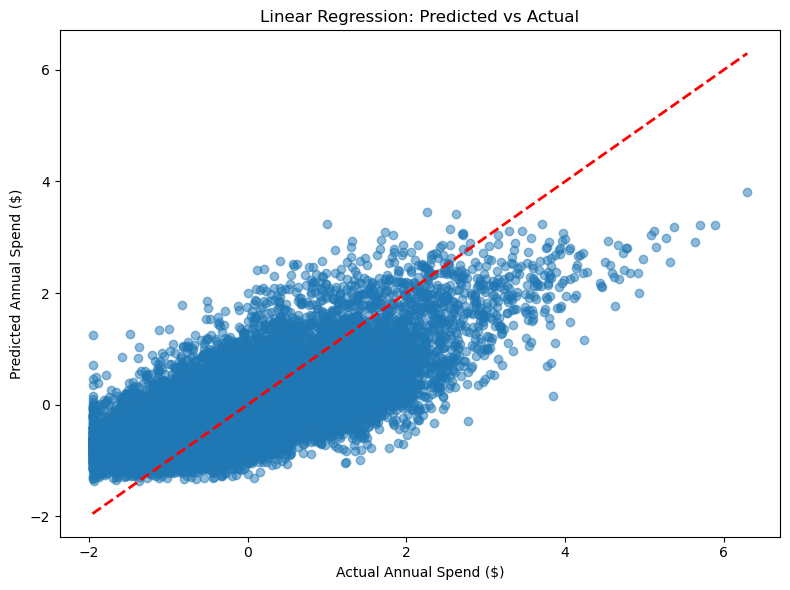

In [65]:
# Visualize: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Annual Spend ($)')
plt.ylabel('Predicted Annual Spend ($)')
plt.title('Linear Regression: Predicted vs Actual')
plt.tight_layout()
plt.show()

### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** What does the R² value tell you in plain English? (Hint: An R² of 0.65 means...)

The R² method shows the difference in a target value and the predicted value. A 1.0 would be perfect and a 0 would be no better than the mean.

---

## Part 5: Logistic Regression

**The Problem:** Now let's switch to **classification**. ShopSmart wants to predict which customers are likely to churn (leave).

**Logistic Regression** predicts the *probability* of belonging to a class.

### Task 5a: Train a Logistic Regression Model

In [66]:
def train_logistic_regression(X_train, y_train):
    """
    Train a logistic regression model for classification.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target (churned: 0 or 1)
        
    Returns:
        LogisticRegression: The trained model
    """
    # Your code here
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    return model

In [67]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train the model
logreg_model = train_logistic_regression(X_train_clf, y_train_clf)

# Basic Verification
assert logreg_model is not None, "Function returned None"
assert hasattr(logreg_model, 'coef_'), "Model should be fitted"

# Make predictions
y_pred_logreg = logreg_model.predict(X_test_clf)
assert set(y_pred_logreg).issubset({0, 1}), "Predictions should be 0 or 1"

# Get probabilities
y_prob_logreg = logreg_model.predict_proba(X_test_clf)[:, 1]
assert y_prob_logreg.min() >= 0 and y_prob_logreg.max() <= 1, "Probabilities should be between 0 and 1"

print("[PASS] Part 5 Tests Passed!")
print(f"\nModel trained successfully")
print(f"Predictions made for {len(y_pred_logreg)} customers")

[PASS] Part 5 Tests Passed!

Model trained successfully
Predictions made for 20000 customers


### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** How is logistic regression different from linear regression, even though both have "regression" in the name?

Logistic Regression is a classification model while Linear Regression is a regression model. Regression models are used for predicting umbers while logistic regression is used for prediction categories.

---

## Part 6: Classification Evaluation

**The Problem:** For classification, we need different metrics than regression.

### Key Classification Metrics:
- **Accuracy**: % of correct predictions. Can be misleading with imbalanced classes!
- **Precision**: Of all predicted churners, how many actually churned? (Avoid false alarms)
- **Recall**: Of all actual churners, how many did we catch? (Don't miss real churners)
- **F1 Score**: Harmonic mean of precision and recall. Good balance.

### Task: Create Classification Evaluation Functions

In [68]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification predictions using multiple metrics.
    
    Args:
        y_true: Actual labels (0 or 1)
        y_pred: Predicted labels (0 or 1)
        
    Returns:
        dict: Dictionary with keys 'accuracy', 'precision', 'recall', 'f1'
    """
    # Your code here
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

In [69]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """
    Plot a confusion matrix heatmap.
    
    Args:
        y_true: Actual labels
        y_pred: Predicted labels
        title: Plot title
    """
    # Your code here
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Actual labels', 'Predicted labels'])
    disp.plot(cmap='Blues', ax=plt.gca())

    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [70]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Evaluate logistic regression
logreg_metrics = evaluate_classification(y_test_clf, y_pred_logreg)

# Basic Verification
assert logreg_metrics is not None, "Function returned None"
assert isinstance(logreg_metrics, dict), "Function should return a dictionary"
assert 'accuracy' in logreg_metrics, "Missing 'accuracy' key"
assert 'precision' in logreg_metrics, "Missing 'precision' key"
assert 'recall' in logreg_metrics, "Missing 'recall' key"
assert 'f1' in logreg_metrics, "Missing 'f1' key"
assert 0 <= logreg_metrics['accuracy'] <= 1, "Accuracy should be between 0 and 1"

print("[PASS] Part 6 Tests Passed!")
print(f"\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {logreg_metrics['accuracy']:.4f}")
print(f"Precision: {logreg_metrics['precision']:.4f}")
print(f"Recall:    {logreg_metrics['recall']:.4f}")
print(f"F1 Score:  {logreg_metrics['f1']:.4f}")

[PASS] Part 6 Tests Passed!

=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  0.7447
Precision: 0.6710
Recall:    0.4050
F1 Score:  0.5051


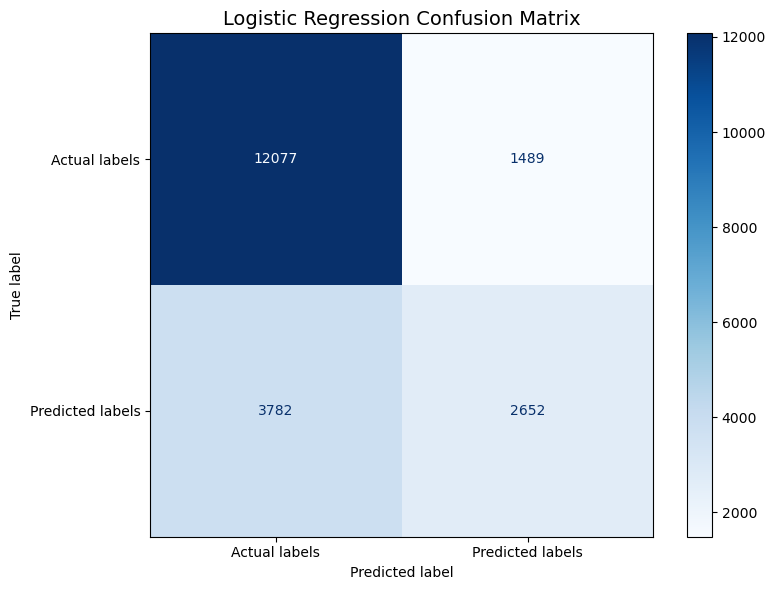

In [27]:
# Plot confusion matrix for logistic regression
plot_confusion_matrix(y_test_clf, y_pred_logreg, 'Logistic Regression Confusion Matrix')

### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** For churn prediction, is **precision** or **recall** more important to ShopSmart? Why? (Hint: Think about the cost of false positives vs false negatives)

**Question 2:** If we predicted "no churn" for everyone, what would our accuracy be? Why is this misleading?

*(Double-click here to write your answers)*

**Answer 1:** Recall is more important. We would rather falsely flag a customer who is not going to leave than miss a customer who does leave because we did not flag them for a possible churn.

**Answer 2:** If we predicted no churn, we would miss every customer who did leave. It would be misleading because you almost always have customers who do not come back the following year.

---

## Part 7: Decision Trees

**The Problem:** Logistic regression is a linear model - it can only learn linear relationships. **Decision Trees** can capture non-linear patterns!

Decision trees work by asking a series of yes/no questions to split the data. They're also highly **interpretable** - you can see exactly why a prediction was made.

### Task: Train a Decision Tree Classifier

In [71]:
def train_decision_tree(X_train, y_train, max_depth=5):
    """
    Train a decision tree classifier.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target
        max_depth (int): Maximum depth of the tree (default 5)
        
    Returns:
        DecisionTreeClassifier: The trained model
    """
    # Your code here
    model = DecisionTreeClassifier(max_depth=max_depth)
    model.fit(X_train, y_train)
    return model

In [72]:
def get_feature_importance(model, feature_names):
    """
    Get feature importances from a tree-based model.
    
    Args:
        model: A fitted tree-based model (has feature_importances_ attribute)
        feature_names: List of feature names
        
    Returns:
        pd.DataFrame: DataFrame with columns 'feature' and 'importance', sorted by importance descending
    """
    # Your code here
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    importance_df = importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    return importance_df

In [73]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train the decision tree
dt_model = train_decision_tree(X_train_clf, y_train_clf, max_depth=5)

# Basic Verification
assert dt_model is not None, "Function returned None"
assert hasattr(dt_model, 'tree_'), "Model should be fitted"

# Make predictions
y_pred_dt = dt_model.predict(X_test_clf)

# Get feature importance
importance_df = get_feature_importance(dt_model, X_train_clf.columns.tolist())
assert importance_df is not None, "Feature importance function returned None"
assert 'feature' in importance_df.columns, "Missing 'feature' column"
assert 'importance' in importance_df.columns, "Missing 'importance' column"
assert abs(importance_df['importance'].sum() - 1.0) < 0.01, "Importances should sum to ~1"

# Evaluate
dt_metrics = evaluate_classification(y_test_clf, y_pred_dt)

print("[PASS] Part 7 Tests Passed!")
print(f"\n=== DECISION TREE RESULTS ===")
print(f"Accuracy:  {dt_metrics['accuracy']:.4f}")
print(f"Precision: {dt_metrics['precision']:.4f}")
print(f"Recall:    {dt_metrics['recall']:.4f}")
print(f"F1 Score:  {dt_metrics['f1']:.4f}")

[PASS] Part 7 Tests Passed!

=== DECISION TREE RESULTS ===
Accuracy:  0.7509
Precision: 0.6465
Recall:    0.4980
F1 Score:  0.5626


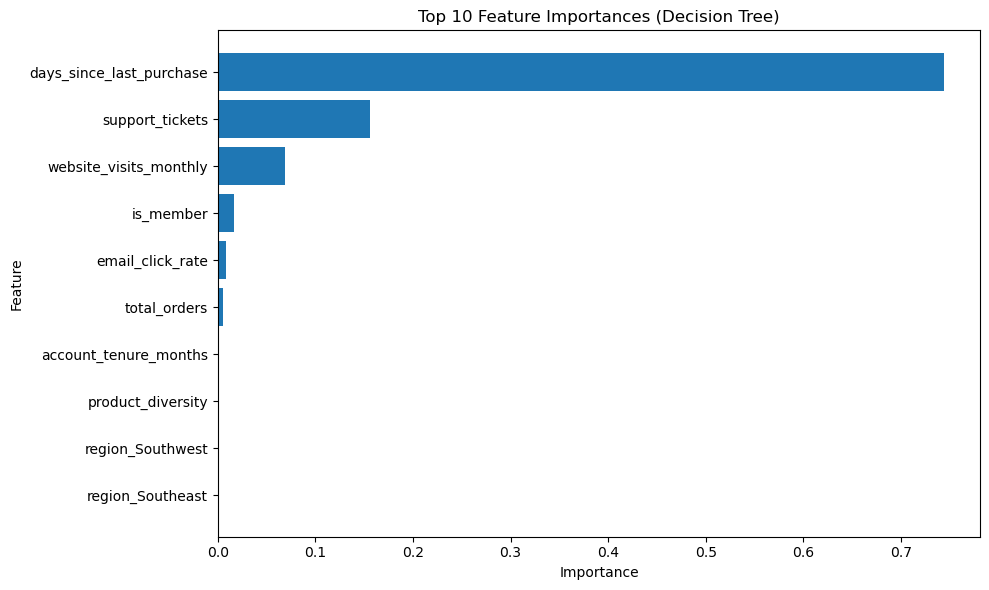

In [74]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

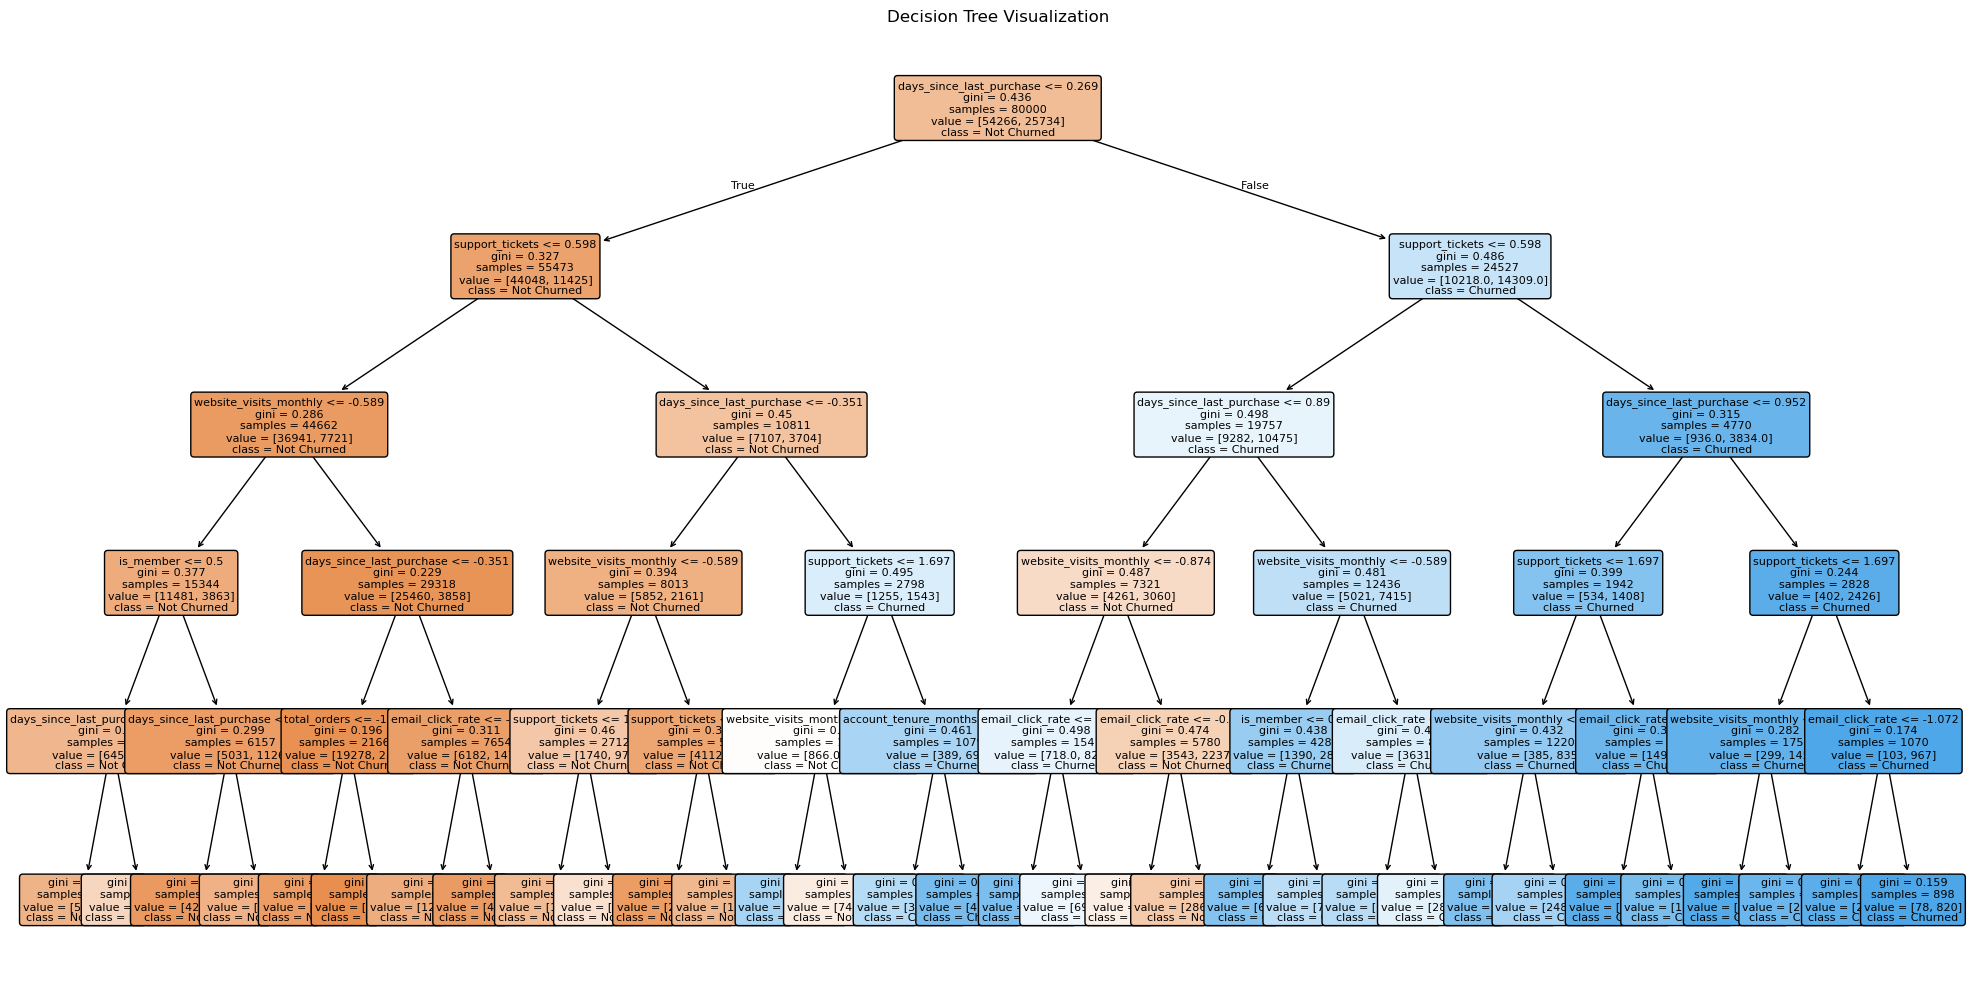

In [75]:
# Visualize the decision tree (optional but insightful!)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_train_clf.columns.tolist(), 
          class_names=['Not Churned', 'Churned'], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** Compare the decision tree results to logistic regression. Which performed better? Looking at the feature importances, what features are most predictive of churn?

The Decision Tree Classifier performed better than the performed better than Logistical Regression. The feature that let to the largest churn was customers who had not made purchases in a long period of time. The next was customers who filled lots of complaints. 

---

## Part 8: Random Forest with Hyperparameter Tuning

**The Problem:** A single decision tree can overfit. **Random Forest** creates many trees and averages their predictions - this is called **bagging** (bootstrap aggregating).

### Key Hyperparameters:
- **n_estimators**: Number of trees in the forest (more = better but slower)
- **max_depth**: Maximum depth of each tree (controls overfitting)

### Task: Train and Tune a Random Forest

In [76]:
def train_random_forest(X_train, y_train, n_estimators=100, max_depth=None):
    """
    Train a random forest classifier.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target
        n_estimators (int): Number of trees (default 100)
        max_depth (int or None): Maximum depth of trees (default None = unlimited)
        
    Returns:
        RandomForestClassifier: The trained model
    """
    # Your code here
    
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
    model.fit(X_train, y_train)
    return model

In [77]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train a basic random forest first
rf_model = train_random_forest(X_train_clf, y_train_clf, n_estimators=100, max_depth=10)

# Basic Verification
assert rf_model is not None, "Function returned None"
assert hasattr(rf_model, 'estimators_'), "Model should be fitted"
assert len(rf_model.estimators_) == 100, "Should have 100 trees"

# Make predictions
y_pred_rf = rf_model.predict(X_test_clf)
rf_metrics = evaluate_classification(y_test_clf, y_pred_rf)

print("[PASS] Part 8 Basic Tests Passed!")
print(f"\n=== RANDOM FOREST BASELINE ===")
print(f"Accuracy:  {rf_metrics['accuracy']:.4f}")
print(f"F1 Score:  {rf_metrics['f1']:.4f}")

[PASS] Part 8 Basic Tests Passed!

=== RANDOM FOREST BASELINE ===
Accuracy:  0.7532
F1 Score:  0.5396


### Hyperparameter Tuning Task

Now experiment with different hyperparameters! Try at least **3 different combinations** and track the results.

**Note:** This cell may take 1-2 minutes to run since we're training multiple models on 80,000 rows. Be patient!

Suggested combinations to try:
- n_estimators: 50, 100, 200
- max_depth: 5, 10, None (unlimited)

In [35]:
# YOUR HYPERPARAMETER TUNING CODE HERE
# Try at least 3 different combinations and track the results

# Example structure:
# results = []
# for n_est in [50, 100, 200]:
#     for depth in [5, 10, None]:
#         model = train_random_forest(X_train_clf, y_train_clf, n_estimators=n_est, max_depth=depth)
#         y_pred = model.predict(X_test_clf)
#         metrics = evaluate_classification(y_test_clf, y_pred)
#         results.append({'n_estimators': n_est, 'max_depth': depth, 'f1': metrics['f1']})
#
# results_df = pd.DataFrame(results)
# print(results_df.sort_values('f1', ascending=False))

# Your code here:
results = []
for n_est in [50, 100, 200, 400]:
    for depth in [5, 10, None]:
        model = train_random_forest(X_train_clf, y_train_clf, n_estimators=n_est, max_depth=depth)
        y_pred = model.predict(X_test_clf)
        metrics = evaluate_classification(y_test_clf, y_pred)
        results.append({'n_estimators': n_est, 'max_depth': depth, 'f1': metrics['f1']})

results_df = pd.DataFrame(results)
print(results_df.sort_values('f1', ascending=False))

    n_estimators  max_depth        f1
10           400       10.0  0.553398
4            100       10.0  0.552697
7            200       10.0  0.550005
11           400        NaN  0.546450
1             50       10.0  0.545218
5            100        NaN  0.544756
8            200        NaN  0.541774
2             50        NaN  0.532782
3            100        5.0  0.468583
0             50        5.0  0.434307
6            200        5.0  0.430773
9            400        5.0  0.428303


In [36]:
# Train your BEST random forest model based on tuning
# Update the hyperparameters based on your experiments!

best_rf_model = train_random_forest(X_train_clf, y_train_clf, 
                                     n_estimators=100,  # UPDATE THIS
                                     max_depth=10)      # UPDATE THIS

y_pred_best_rf = best_rf_model.predict(X_test_clf)
best_rf_metrics = evaluate_classification(y_test_clf, y_pred_best_rf)

print(f"\n=== BEST RANDOM FOREST ===")
print(f"Accuracy:  {best_rf_metrics['accuracy']:.4f}")
print(f"Precision: {best_rf_metrics['precision']:.4f}")
print(f"Recall:    {best_rf_metrics['recall']:.4f}")
print(f"F1 Score:  {best_rf_metrics['f1']:.4f}")


=== BEST RANDOM FOREST ===
Accuracy:  0.7533
Precision: 0.6744
Recall:    0.4510
F1 Score:  0.5406


### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Why does Random Forest often outperform a single decision tree?

**Question 2:** How did changing the hyperparameters affect performance? What was your best combination?

*(Double-click here to write your answers)*

**Answer 1:** Decision trees are worse at generalization than random forests. Decision trees while good at training accuracy, they can also lead to over-fitting.

**Answer 2:** Adding different estimators and depth altered the accuracy of the predictions. The best combination was 100 for the estimators and 10 for the depth, which was the same in the first example.

---

## Part 9: Gradient Boosting with Hyperparameter Tuning

**The Problem:** Random Forest builds trees in parallel (bagging). **Gradient Boosting** builds trees sequentially - each tree tries to correct the errors of the previous one. This is called **boosting**.

### Key Hyperparameters:
- **n_estimators**: Number of boosting stages (trees built sequentially)
- **learning_rate**: How much each tree contributes (smaller = more trees needed but often better)

### Task: Train and Tune Gradient Boosting

In [37]:
def train_gradient_boosting(X_train, y_train, n_estimators=100, learning_rate=0.1):
    """
    Train a gradient boosting classifier.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target
        n_estimators (int): Number of boosting stages (default 100)
        learning_rate (float): Learning rate (default 0.1)
        
    Returns:
        GradientBoostingClassifier: The trained model
    """
    # Your code here
    
    model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate)
    model.fit(X_train, y_train)
    return model

In [38]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train a basic gradient boosting model
gb_model = train_gradient_boosting(X_train_clf, y_train_clf, n_estimators=100, learning_rate=0.1)

# Basic Verification
assert gb_model is not None, "Function returned None"
assert hasattr(gb_model, 'estimators_'), "Model should be fitted"

# Make predictions
y_pred_gb = gb_model.predict(X_test_clf)
gb_metrics = evaluate_classification(y_test_clf, y_pred_gb)

print("[PASS] Part 9 Basic Tests Passed!")
print(f"\n=== GRADIENT BOOSTING BASELINE ===")
print(f"Accuracy:  {gb_metrics['accuracy']:.4f}")
print(f"F1 Score:  {gb_metrics['f1']:.4f}")

[PASS] Part 9 Basic Tests Passed!

=== GRADIENT BOOSTING BASELINE ===
Accuracy:  0.7569
F1 Score:  0.5627


### Hyperparameter Tuning Task

Experiment with different hyperparameters! Try at least **3 different combinations**.

**Note:** This cell may take 2-3 minutes to run since Gradient Boosting trains trees sequentially. Be patient!

Suggested combinations to try:
- n_estimators: 50, 100, 200
- learning_rate: 0.01, 0.1, 0.2

In [39]:
# HYPERPARAMETER TUNING CODE
# Try at least 3 different combinations and track the results

results = []
for n_est in [50, 100, 200]:
    for lr in [0.01, 0.1, 0.2]:
        model = train_gradient_boosting(X_train_clf, y_train_clf, n_estimators=n_est, learning_rate=lr)
        y_pred = model.predict(X_test_clf)
        metrics = evaluate_classification(y_test_clf, y_pred)
        results.append({'n_estimators': n_est, 'learning_rate': lr, 'f1': metrics['f1']})

results_df = pd.DataFrame(results)
print(results_df.sort_values('f1', ascending=False))

   n_estimators  learning_rate        f1
4           100           0.10  0.562719
1            50           0.10  0.561224
7           200           0.10  0.560577
2            50           0.20  0.559667
5           100           0.20  0.556822
8           200           0.20  0.555505
6           200           0.01  0.552622
3           100           0.01  0.385822
0            50           0.01  0.193477


In [40]:
# Train your BEST gradient boosting model based on tuning
# Update the hyperparameters based on your experiments!

best_gb_model = train_gradient_boosting(X_train_clf, y_train_clf,
                                         n_estimators=100,    # UPDATE THIS
                                         learning_rate=0.1)   # UPDATE THIS

y_pred_best_gb = best_gb_model.predict(X_test_clf)
best_gb_metrics = evaluate_classification(y_test_clf, y_pred_best_gb)

print(f"\n=== BEST GRADIENT BOOSTING ===")
print(f"Accuracy:  {best_gb_metrics['accuracy']:.4f}")
print(f"Precision: {best_gb_metrics['precision']:.4f}")
print(f"Recall:    {best_gb_metrics['recall']:.4f}")
print(f"F1 Score:  {best_gb_metrics['f1']:.4f}")


=== BEST GRADIENT BOOSTING ===
Accuracy:  0.7569
Precision: 0.6676
Recall:    0.4863
F1 Score:  0.5627


### Written Reflection
> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** What's the key difference between **bagging** (Random Forest) and **boosting** (Gradient Boosting)?

**Question 2:** Which ensemble method performed better on this dataset? Why might that be?

*(Double-click here to write your answers)*

**Answer 1:** Bagging is when we chain multiple models together in parallel and boosting is when we run multiple models in sequence.

**Answer 2:** Gradient boosting performed slightly better. Boosting probably outperforms because it does better out finding rare patterns.

---

## Part 10: Model Comparison & Business Recommendations

**The Problem:** You've built many models. Now ShopSmart needs to know which one to deploy!

### Task: Create a Model Comparison Table

In [41]:
# Create a comparison DataFrame for all classification models
# Include: Logistic Regression, Decision Tree, Random Forest (best), Gradient Boosting (best)

comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        logreg_metrics['accuracy'],
        dt_metrics['accuracy'],
        best_rf_metrics['accuracy'],
        best_gb_metrics['accuracy']
    ],
    'Precision': [
        logreg_metrics['precision'],
        dt_metrics['precision'],
        best_rf_metrics['precision'],
        best_gb_metrics['precision']
    ],
    'Recall': [
        logreg_metrics['recall'],
        dt_metrics['recall'],
        best_rf_metrics['recall'],
        best_gb_metrics['recall']
    ],
    'F1': [
        logreg_metrics['f1'],
        dt_metrics['f1'],
        best_rf_metrics['f1'],
        best_gb_metrics['f1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=== MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

=== MODEL COMPARISON ===
              Model  Accuracy  Precision   Recall       F1
Logistic Regression   0.73645   0.640425 0.412185 0.501560
      Decision Tree   0.75090   0.646489 0.497979 0.562599
      Random Forest   0.75335   0.674413 0.451041 0.540561
  Gradient Boosting   0.75685   0.667591 0.486323 0.562719


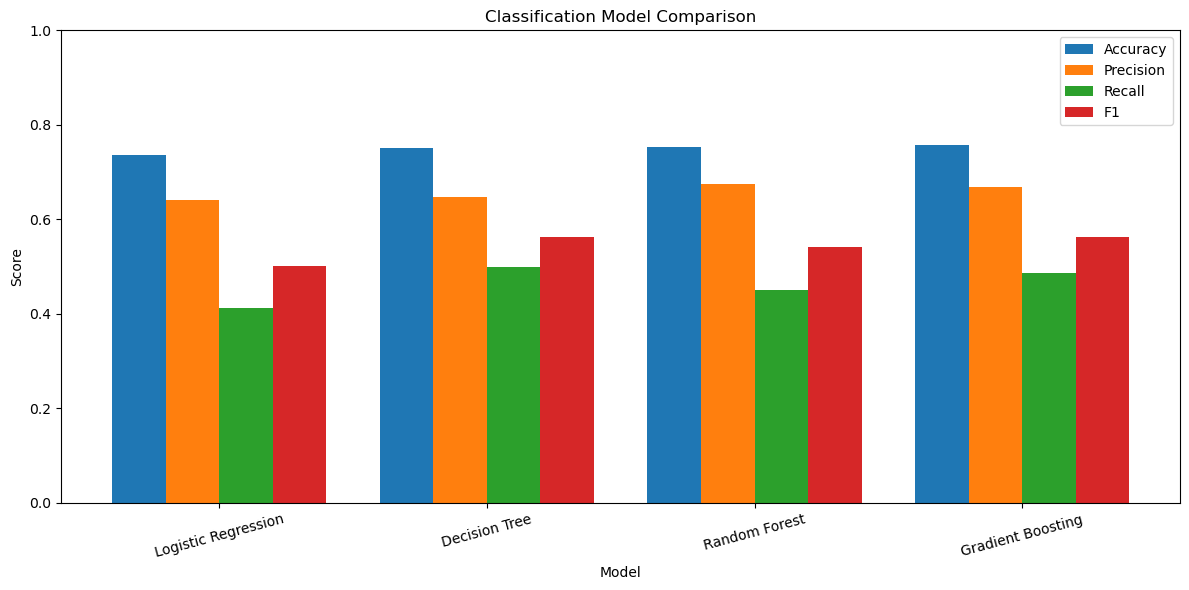

In [42]:
# Visualize the comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']

x = np.arange(len(comparison_df['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, comparison_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

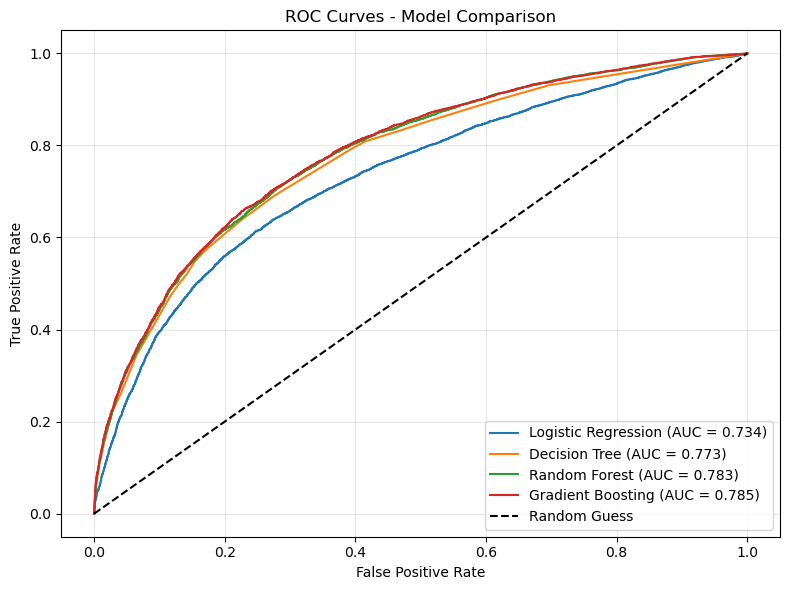

In [43]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))

models_for_roc = [
    ('Logistic Regression', logreg_model),
    ('Decision Tree', dt_model),
    ('Random Forest', best_rf_model),
    ('Gradient Boosting', best_gb_model)
]

for name, model in models_for_roc:
    y_prob = model.predict_proba(X_test_clf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Business Recommendations

> **Please answer the questions below. They are a required part of the assignment!**

**Question 1:** Which model would you recommend ShopSmart deploy for churn prediction? Why?

**Question 2:** Based on your analysis, what are the **top 3 features** that predict customer churn?

**Question 3:** What specific actions should ShopSmart take to reduce customer churn?

*(Double-click here to write your answers)*

**Answer 1 - Recommended Model:** I would recommend gradient boosting for churn prediction.

**Answer 2 - Top 3 Churn Predictors:** The top features that predict customer churn are length of time since last time they shopped, the number of complaints the customer has made and the number of times they have visited the website.

**Answer 3 - Churn Reduction Recommendations:** Market to the customers that have not shopped or visited the website recently, and address issues that were common in their complaints.

---

## Final Summary

Run this cell to see a summary of everything you built!

In [44]:
print("="*60)
print("UNIT 3 CAPSTONE SUMMARY")
print("="*60)

print(f"\nDATASET")
print(f"   Customers: 100,000")
print(f"   Features: {X_train_clf.shape[1]}")
print(f"   Churn Rate: {y_train_clf.mean():.1%}")

print(f"\nREGRESSION (Predicting Annual Spend)")
print(f"   Linear Regression R²: {reg_metrics['r2']:.4f}")
print(f"   RMSE: ${reg_metrics['rmse']:,.2f}")

print(f"\nCLASSIFICATION (Predicting Churn)")
print(f"   Best Model: {comparison_df.loc[comparison_df['F1'].idxmax(), 'Model']}")
print(f"   Best F1 Score: {comparison_df['F1'].max():.4f}")

print(f"\nMODELS BUILT")
print(f"   1. Linear Regression")
print(f"   2. Logistic Regression")
print(f"   3. Decision Tree")
print(f"   4. Random Forest (tuned)")
print(f"   5. Gradient Boosting (tuned)")

print("\n" + "="*60)
print("Great work completing Unit 3!")
print("="*60)

UNIT 3 CAPSTONE SUMMARY

DATASET
   Customers: 100,000
   Features: 17
   Churn Rate: 32.2%

REGRESSION (Predicting Annual Spend)
   Linear Regression R²: 0.4789
   RMSE: $689.12

CLASSIFICATION (Predicting Churn)
   Best Model: Gradient Boosting
   Best F1 Score: 0.5627

MODELS BUILT
   1. Linear Regression
   2. Logistic Regression
   3. Decision Tree
   4. Random Forest (tuned)
   5. Gradient Boosting (tuned)

Great work completing Unit 3!


---

## Ready to Submit?

### Checklist:
- [ ] All **assert tests pass** (no errors when running the test cells)
- [ ] All **Written Reflections** are answered thoughtfully
- [ ] **Hyperparameter tuning** was performed for Random Forest and Gradient Boosting
- [ ] **Business recommendations** are specific and actionable
- [ ] Code has **comments** explaining your logic

### Submission:
Turn in your completed notebook on Canvas by the due date.

Remember: You can resubmit after receiving feedback!

---

*Congratulations on completing the Machine Learning capstone! You've built real predictive models that could help a business make data-driven decisions.*